In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import import_ipynb
import genetic_algorithm
import NSGA2
import simulated_annealing
import BPSO

from evaluators.knn_evaluator import evaluate_all_features_knn, evaluate_selected_features_knn, evaluate_on_test_knn
from evaluators.random_forest_evaluator import evaluate_all_features_rf, evaluate_selected_features_rf, evaluate_on_test_rf
from evaluators.svc_evaluator import evaluate_all_features_svc, evaluate_selected_features_svc, evaluate_on_test_svc

# IONOSPHERE

**Loading dataset: Ionosphere**

In [8]:
X_train_ionosphere = pd.read_csv("../datasets/ionosphere/X_train.csv")
y_train_ionosphere = pd.read_csv('../datasets/ionosphere/y_train.csv').to_numpy().ravel()
X_test_ionosphere = pd.read_csv("../datasets/ionosphere/X_test.csv")
y_test_ionosphere = pd.read_csv("../datasets/ionosphere/y_test.csv").to_numpy().ravel()

In [10]:
avg_acc_train, acc_test = evaluate_all_features_rf(X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Average train accuracy (RF): {avg_acc_train:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Average train accuracy (RF): 0.9469
Test accuracy (RF): 0.9151


accuracy: 0.9387755102040817 features percentage: 0.20588235294117646
accuracy: 0.9306122448979591 features percentage: 0.14705882352941177
accuracy: 0.9510204081632653 features percentage: 0.23529411764705882
accuracy: 0.9061224489795918 features percentage: 0.08823529411764706
accuracy: 0.9183673469387756 features percentage: 0.11764705882352941


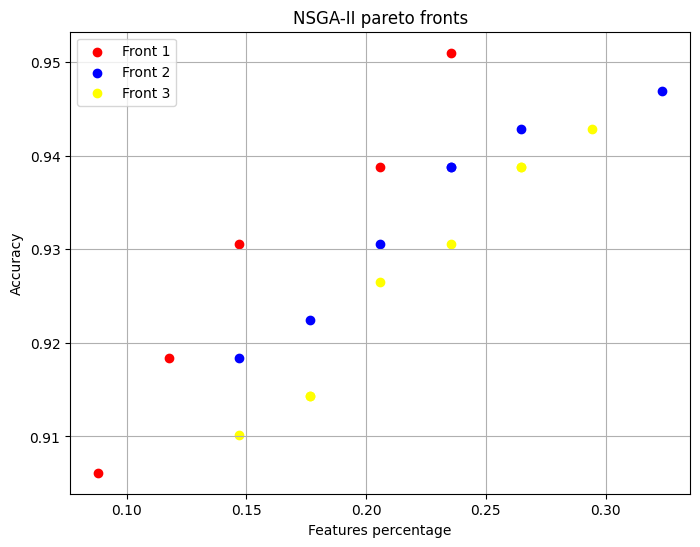

In [11]:
nsga = NSGA2.NSGA2(X_train_ionosphere, y_train_ionosphere, calc_accuracy_fn=evaluate_selected_features_rf,
                   population_size=20, num_generations=20, feature_probability=0.5,mutation_probability=0.1,
                   use_adaptive_mutatation=True)
pareto, fig = nsga.run()
fig.savefig("../images/ds1_NSGA2_fronts.png", dpi = 300)

In [12]:
number_selected_features = [int(sum(i.code)) for i in pareto]
print(f"Number selected features in Pareto front: {number_selected_features}")

Number selected features in Pareto front: [7, 5, 8, 3, 4]


In [13]:
acc_test = evaluate_on_test_rf(pareto[0].code, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Test accuracy (RF): {acc_test:.4f}")

Test accuracy (RF): 0.8868


In [14]:
ga_ionosphere = genetic_algorithm.GA( X_train_ionosphere ,y_train_ionosphere ,calc_accuracy_fn= evaluate_selected_features_rf,
                          population_size = 20, num_generations = 50, tournament_size=4, selection_method = "tournament" ,
                          mutation_probability = 0.1,alpha = 0.5,elitism_size = 3,patience = 10,use_heuristic = False
                          ,initial_feature_percentage = 0.5,use_adaptive_mutatation=True)
best_solution,best_train_accuracy,number_selected_features, best_fitness, history = ga_ionosphere.run()

Generation: 0 best fitnes: 0.7765906362545018
Generation: 1 best fitnes: 0.7827130852340936
Generation: 2 best fitnes: 0.8129651860744297
Generation: 3 best fitnes: 0.8186674669867948
Generation: 4 best fitnes: 0.8521608643457383
Generation: 5 best fitnes: 0.8521608643457383
Generation: 6 best fitnes: 0.854201680672269
Generation: 7 best fitnes: 0.8627851140456182
Generation: 8 best fitnes: 0.8648259303721488
Generation: 9 best fitnes: 0.8648259303721488
Generation: 10 best fitnes: 0.8729891956782712
Generation: 11 best fitnes: 0.8815726290516206
Generation: 12 best fitnes: 0.8815726290516206
Generation: 13 best fitnes: 0.8815726290516206
Generation: 14 best fitnes: 0.8815726290516206
Generation: 15 best fitnes: 0.8815726290516206
Generation: 16 best fitnes: 0.8946578631452581
Generation: 17 best fitnes: 0.8946578631452581
Generation: 18 best fitnes: 0.8946578631452581
Generation: 19 best fitnes: 0.8946578631452581
Generation: 20 best fitnes: 0.9007803121248499
Generation: 21 best fitn

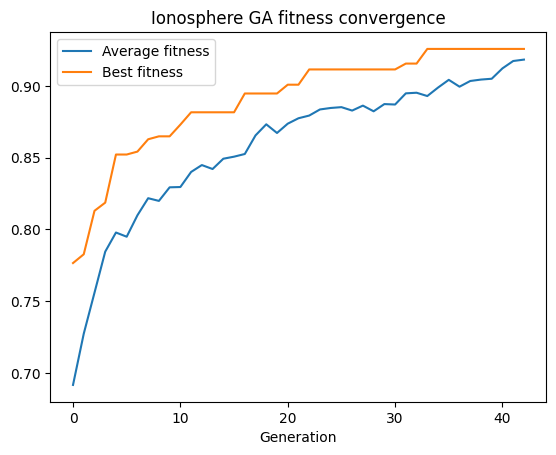

In [15]:
df_history = pd.DataFrame(history,columns = ["Generation","Average fitness","Best fitness"])
plot = df_history.plot(x="Generation", y = ["Average fitness","Best fitness"])
plot.set_title("Ionosphere GA fitness convergence")
plt.savefig("../images/ds1_GA_fc.png", dpi = 300)

In [16]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 2
Feature percentage: 0.0588


In [17]:
acc_test = evaluate_on_test_rf(best_solution, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Train accuracy of best solution (RF): {best_train_accuracy:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (RF): 0.9143
Test accuracy (RF): 0.8868


In [18]:
ga_sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 30,
                 code = best_solution,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_ionosphere,
                 y_train = y_train_ionosphere,
                 calc_accuracy_fn = evaluate_selected_features_rf,
                 patience = 30)

In [19]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = ga_sa_extended.run()

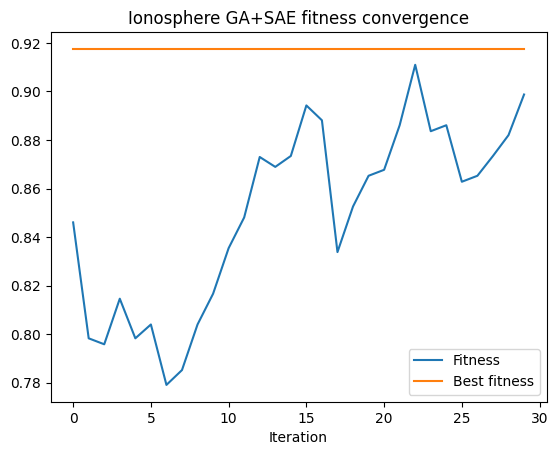

In [20]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Ionosphere GA+SAE fitness convergence")
plt.savefig("../images/ds1_GA+SAE_fc.png", dpi = 300)

In [21]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 2
Feature percentage: 0.0588


In [22]:
acc_test = evaluate_on_test_rf(best_solution, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Train accuracy of best solution (RF): {best_train_acc:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (RF): 0.9143
Test accuracy (RF): 0.8585


In [23]:
best_position, best_train_acc, number_selected_features, best_fitness, best_history, average_history = BPSO.run(
    X_train = X_train_ionosphere,
    y_train = y_train_ionosphere,
    calc_accuracy_fn = evaluate_selected_features_rf,
    alpha = 0.5,
    num_iters = 50,
    swarm_size = 40,
    c_inertia_start = 1.1,
    c_inertia_end = 0.4,
    c_social = 1.0,
    c_cognitive = 2.0
)

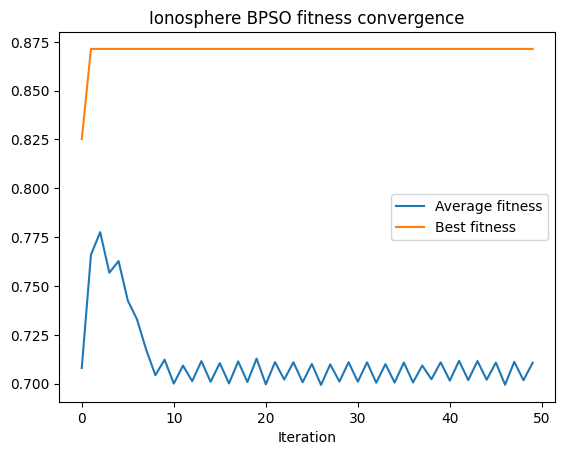

In [24]:
df_avg = pd.DataFrame(average_history, columns=["Iteration", "Average fitness"])
df_best = pd.DataFrame(best_history, columns=["Iteration", "Best fitness"])
df_history = pd.merge(df_avg, df_best, on="Iteration")

plot = df_history.plot(x="Iteration", y = ["Average fitness","Best fitness"])
plot.set_title("Ionosphere BPSO fitness convergence")
plt.savefig("../images/ds1_BPSO_fc.png", dpi = 300)

In [25]:
pct_sel_features = number_selected_features/len(best_position)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 5
Feature percentage: 0.1471


In [26]:
acc_test = evaluate_on_test_rf(best_position, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Train accuracy of best solution (RF): {best_train_acc:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (RF): 0.8776
Test accuracy (RF): 0.8962


In [27]:
bpso_sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 30,
                 code = best_position,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_ionosphere,
                 y_train = y_train_ionosphere,
                 calc_accuracy_fn = evaluate_selected_features_rf,
                 patience = 30)

In [28]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = bpso_sa_extended.run()

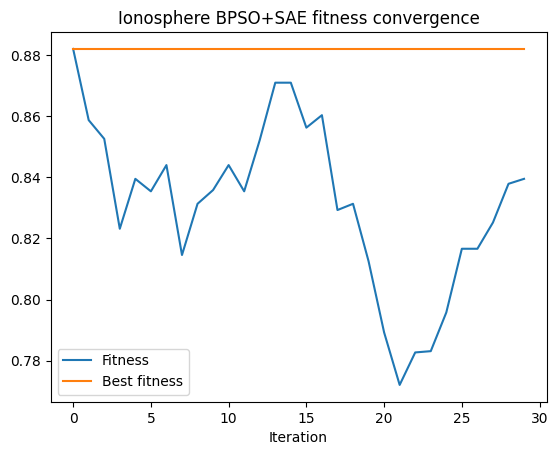

In [29]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Ionosphere BPSO+SAE fitness convergence")
plt.savefig("../images/ds1_BPSO+SAE_fc.png", dpi = 300)

In [30]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 4
Feature percentage: 0.1176


In [31]:
acc_test = evaluate_on_test_rf(best_solution, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Train accuracy of best solution (RF): {best_train_acc:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (RF): 0.8857
Test accuracy (RF): 0.8774


In [32]:
def generate_code(X_train,percentage):
    return (np.random.rand(X_train.shape[1]) < percentage)

In [33]:
initial_code = generate_code(X_train_ionosphere,0.5)

In [34]:
sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 100,
                 code = initial_code,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_ionosphere,
                 y_train = y_train_ionosphere,
                 calc_accuracy_fn = evaluate_selected_features_rf,
                 patience = 30)

In [35]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = sa_extended.run()

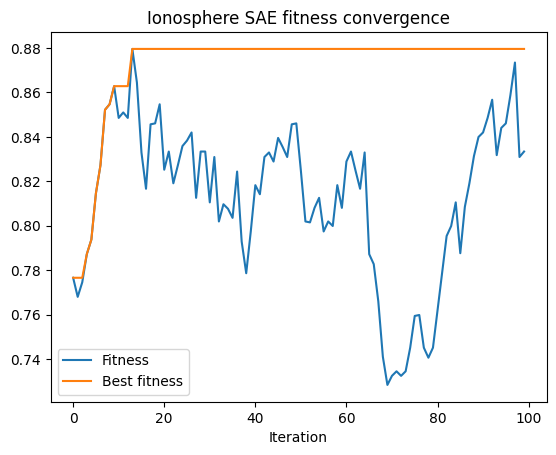

In [36]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Ionosphere SAE fitness convergence")
plt.savefig("../images/ds1_SAE_fc.png", dpi = 300)

In [37]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 5
Feature percentage: 0.1471


In [38]:
acc_test = evaluate_on_test_rf(best_solution, X_train_ionosphere, y_train_ionosphere, X_test_ionosphere, y_test_ionosphere)
print(f"Train accuracy of best solution (RF): {best_train_acc:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (RF): 0.8816
Test accuracy (RF): 0.8774


# ORAL TOXICITY

**Loading dataset: Oral toxicity**

In [4]:
X_train_toxicity = pd.read_csv("../datasets/oral_toxicity/X_train.csv")
y_train_toxicity = pd.read_csv('../datasets/oral_toxicity/y_train.csv').to_numpy().ravel()
X_test_toxicity = pd.read_csv("../datasets/oral_toxicity/X_test.csv")
y_test_toxicity = pd.read_csv("../datasets/oral_toxicity/y_test.csv").to_numpy().ravel()

In [106]:
avg_acc_train, acc_test = evaluate_all_features_knn(X_train_toxicity, y_train_toxicity, X_test_toxicity, y_test_toxicity)
print(f"Average train accuracy (KNN): {avg_acc_train:.4f}\nTest accuracy (KNN): {acc_test:.4f}")

Average train accuracy (KNN): 0.9310
Test accuracy (KNN): 0.9314


accuracy: 0.9169125993189556 features percentage: 0.0361328125
accuracy: 0.9164585698070373 features percentage: 0.0341796875
accuracy: 0.917593643586833 features percentage: 0.0400390625
accuracy: 0.9209988649262202 features percentage: 0.0419921875
accuracy: 0.9359818388195233 features percentage: 0.23828125
accuracy: 0.9234960272417707 features percentage: 0.0556640625
accuracy: 0.9237230419977298 features percentage: 0.0576171875
accuracy: 0.932122587968218 features percentage: 0.0888671875
accuracy: 0.9225879682179341 features percentage: 0.046875
accuracy: 0.9278093076049944 features percentage: 0.0625
accuracy: 0.9225879682179341 features percentage: 0.046875
accuracy: 0.9350737797956867 features percentage: 0.126953125
accuracy: 0.9303064699205448 features percentage: 0.0869140625
accuracy: 0.9364358683314414 features percentage: 0.2392578125
accuracy: 0.9282633371169127 features percentage: 0.068359375


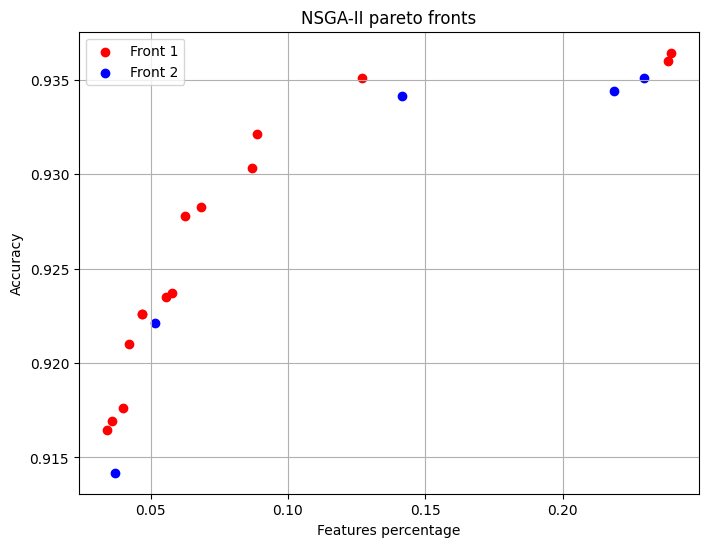

In [48]:
nsga = NSGA2.NSGA2(X_train_toxicity, y_train_toxicity, calc_accuracy_fn=evaluate_selected_features_knn,
                   population_size=20, num_generations=20, feature_probability=0.05,mutation_probability=0.1,
                   use_adaptive_mutatation=True)
pareto, fig = nsga.run()
fig.savefig("../images/ds2_NSGA2_fronts.png", dpi = 300)

In [49]:
number_selected_features = [int(sum(i.code)) for i in pareto]
print(f"Number selected features in Pareto front: {number_selected_features}")

Number selected features in Pareto front: [37, 35, 41, 43, 244, 57, 59, 91, 48, 64, 48, 130, 89, 245, 70]


In [50]:
acc_test = evaluate_on_test_knn(pareto[0].code, X_train_toxicity, y_train_toxicity, X_test_toxicity, y_test_toxicity)
print(f"Test accuracy (KNN): {acc_test:.4f}")

Test accuracy (KNN): 0.9110


In [53]:
ga_toxicity = genetic_algorithm.GA( X_train_toxicity ,y_train_toxicity ,calc_accuracy_fn= evaluate_selected_features_knn,
                          population_size = 30, num_generations = 100, tournament_size=4, selection_method = "tournament" ,
                          mutation_probability = 0.1,alpha = 0.5,elitism_size = 3,patience = 10,use_heuristic = False
                          ,initial_feature_percentage = 0.5,use_adaptive_mutatation=True)
best_solution,best_train_accuracy,number_selected_features, best_fitness, history = ga_toxicity.run()

Generation: 0 best fitnes: 0.7292791394721907
Generation: 1 best fitnes: 0.7377276798382519
Generation: 2 best fitnes: 0.7427690036180478
Generation: 3 best fitnes: 0.7460734649900681
Generation: 4 best fitnes: 0.751705825234109
Generation: 5 best fitnes: 0.751705825234109
Generation: 6 best fitnes: 0.751705825234109
Generation: 7 best fitnes: 0.751705825234109
Generation: 8 best fitnes: 0.754999534442395
Generation: 9 best fitnes: 0.754999534442395
Generation: 10 best fitnes: 0.7583489997162316
Generation: 11 best fitnes: 0.7583489997162316
Generation: 12 best fitnes: 0.7583489997162316
Generation: 13 best fitnes: 0.7588372809662316
Generation: 14 best fitnes: 0.7588372809662316
Generation: 15 best fitnes: 0.7627435309662316
Generation: 16 best fitnes: 0.7627435309662316
Generation: 17 best fitnes: 0.7627435309662316
Generation: 18 best fitnes: 0.7667182844423951
Generation: 19 best fitnes: 0.7667182844423951
Generation: 20 best fitnes: 0.7667182844423951
Generation: 21 best fitnes: 0

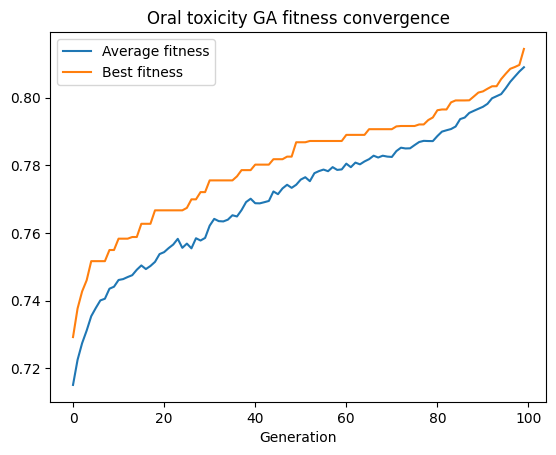

In [54]:
df_history = pd.DataFrame(history,columns = ["Generation","Average fitness","Best fitness"])
plot = df_history.plot(x="Generation", y = ["Average fitness","Best fitness"])
plot.set_title("Oral toxicity GA fitness convergence")
plt.savefig("../images/ds2_GA_fc.png", dpi = 300)

In [55]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 312
Feature percentage: 0.3047


In [58]:
acc_test = evaluate_on_test_knn(best_solution, X_train_toxicity, y_train_toxicity, X_test_toxicity, y_test_toxicity)
print(f"Train accuracy of best solution (KNN): {best_train_accuracy:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (KNN): 0.9335
Test accuracy (RF): 0.9307


In [60]:
ga_sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 30,
                 code = best_solution,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_toxicity,
                 y_train = y_train_toxicity,
                 calc_accuracy_fn = evaluate_selected_features_knn,
                 patience = 30)

In [61]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = ga_sa_extended.run()

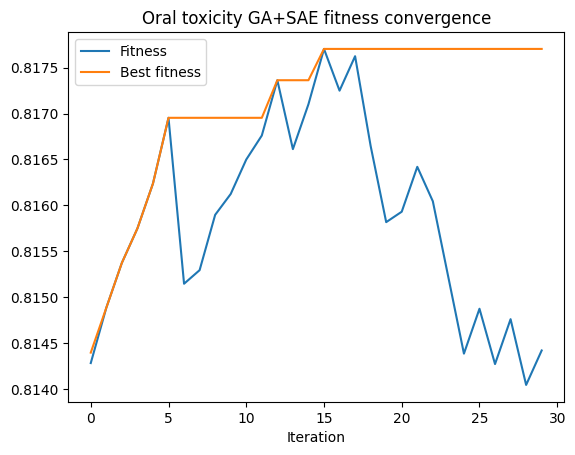

In [62]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Oral toxicity GA+SAE fitness convergence")
plt.savefig("../images/ds2_GA+SAE_fc.png", dpi = 300)

In [63]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 305
Feature percentage: 0.2979


In [64]:
acc_test = evaluate_on_test_knn(best_solution, X_train_toxicity, y_train_toxicity, X_test_toxicity, y_test_toxicity)
print(f"Train accuracy of best solution (KNN): {best_train_acc:.4f}\nTest accuracy (KNN): {acc_test:.4f}")

Train accuracy of best solution (KNN): 0.9333
Test accuracy (KNN): 0.9281


In [65]:
best_position, best_train_acc, number_selected_features, best_fitness, best_history, average_history = BPSO.run(
    X_train = X_train_toxicity,
    y_train = y_train_toxicity,
    calc_accuracy_fn = evaluate_selected_features_knn,
    alpha = 0.5,
    num_iters = 50,
    swarm_size = 40,
    c_inertia_start = 1.1,
    c_inertia_end = 0.4,
    c_social = 1.0,
    c_cognitive = 2.0
)

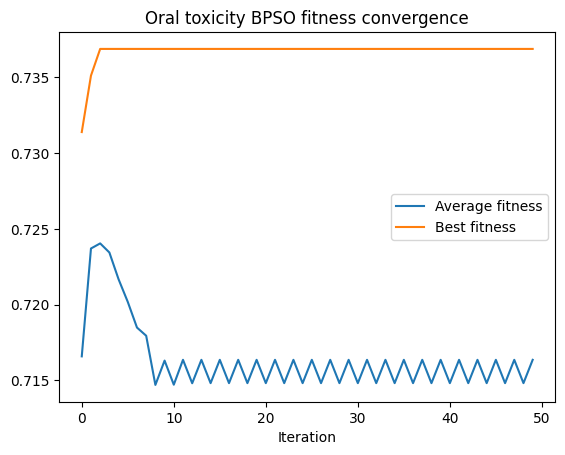

In [66]:
df_avg = pd.DataFrame(average_history, columns=["Iteration", "Average fitness"])
df_best = pd.DataFrame(best_history, columns=["Iteration", "Best fitness"])
df_history = pd.merge(df_avg, df_best, on="Iteration")

plot = df_history.plot(x="Iteration", y = ["Average fitness","Best fitness"])
plot.set_title("Oral toxicity BPSO fitness convergence")
plt.savefig("../images/ds2_BPSO_fc.png", dpi = 300)

In [67]:
pct_sel_features = number_selected_features/len(best_position)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 468
Feature percentage: 0.4570


In [68]:
acc_test = evaluate_on_test_knn(best_position, X_train_toxicity, y_train_toxicity, X_test_toxicity, y_test_toxicity)
print(f"Train accuracy of best solution (KNN): {best_train_acc:.4f}\nTest accuracy (KNN): {acc_test:.4f}")

Train accuracy of best solution (KNN): 0.9308
Test accuracy (KNN): 0.9262


In [71]:
bpso_sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 100,
                 code = best_position,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_toxicity,
                 y_train = y_train_toxicity,
                 calc_accuracy_fn = evaluate_selected_features_knn,
                 patience = 30)

In [72]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = bpso_sa_extended.run()

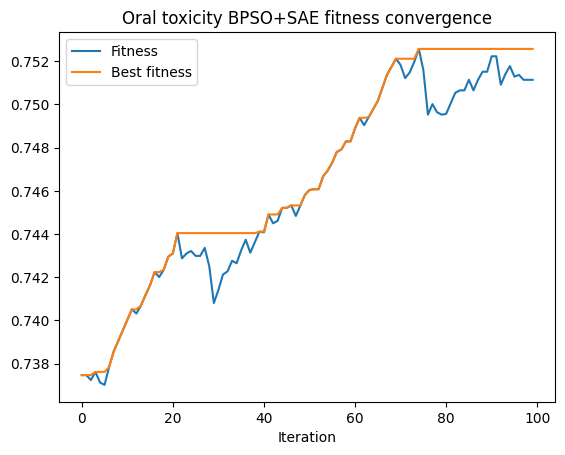

In [73]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Oral toxicity BPSO+SAE fitness convergence")
plt.savefig("../images/ds2_BPSO+SAE_fc.png", dpi = 300)

In [74]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 437
Feature percentage: 0.4268


In [75]:
acc_test = evaluate_on_test_knn(best_solution, X_train_toxicity, y_train_toxicity, X_test_toxicity, y_test_toxicity)
print(f"Train accuracy of best solution (KNN): {best_train_acc:.4f}\nTest accuracy (KNN): {acc_test:.4f}")

Train accuracy of best solution (KNN): 0.9319
Test accuracy (KNN): 0.9311


In [76]:
initial_code = generate_code(X_train_toxicity,0.5)

In [79]:
sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 100,
                 code = initial_code,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_toxicity,
                 y_train = y_train_toxicity,
                 calc_accuracy_fn = evaluate_selected_features_knn,
                 patience = 30)

In [80]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = sa_extended.run()

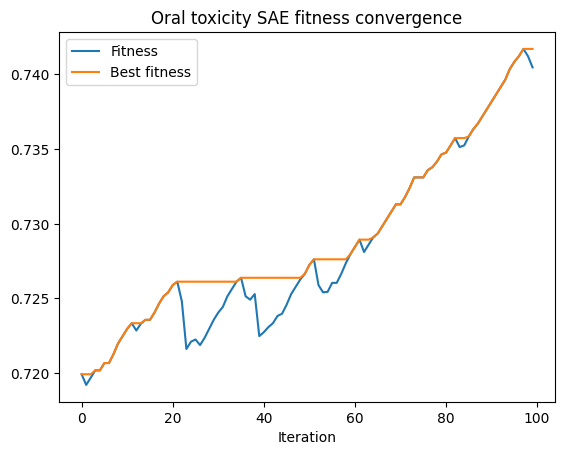

In [81]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Oral toxicity SAE fitness convergence")
plt.savefig("../images/ds2_SAE_fc.png", dpi = 300)

In [82]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 459
Feature percentage: 0.4482


In [84]:
acc_test = evaluate_on_test_knn(best_solution, X_train_toxicity, y_train_toxicity, X_test_toxicity, y_test_toxicity)
print(f"Train accuracy of best solution (KNN): {best_train_acc:.4f}\nTest accuracy (KNN): {acc_test:.4f}")

Train accuracy of best solution (KNN): 0.9317
Test accuracy (KNN): 0.9299


# BREAST CANCER

**Loading dataset: Breast cancer**

In [107]:
X_train_cancer = pd.read_csv("../datasets/breast_cancer/X_train.csv")
y_train_cancer = pd.read_csv('../datasets/breast_cancer/y_train.csv').to_numpy().ravel()
X_test_cancer = pd.read_csv("../datasets/breast_cancer/X_test.csv")
y_test_cancer = pd.read_csv("../datasets/breast_cancer/y_test.csv").to_numpy().ravel()

accuracy: 0.9195569620253166 features percentage: 0.03333333333333333
accuracy: 0.9496835443037975 features percentage: 0.06666666666666667
accuracy: 0.9697784810126583 features percentage: 0.1
accuracy: 0.9773101265822784 features percentage: 0.2
accuracy: 0.9748101265822784 features percentage: 0.16666666666666666
accuracy: 0.9723101265822786 features percentage: 0.13333333333333333


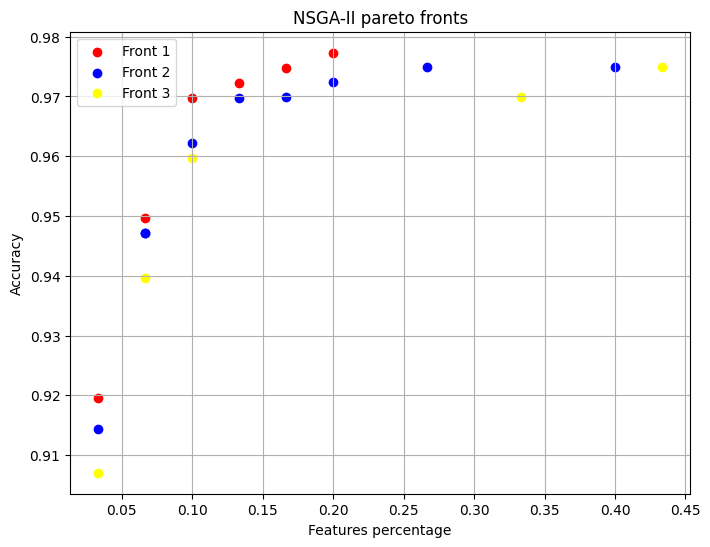

In [110]:
nsga = NSGA2.NSGA2(X_train_cancer, y_train_cancer, calc_accuracy_fn=evaluate_selected_features_knn,
                   population_size=20, num_generations=20, feature_probability=0.1,mutation_probability=0.1,
                   use_adaptive_mutatation=True)
pareto, fig = nsga.run()
fig.savefig("../images/ds3_NSGA2_fronts.png", dpi = 300)

In [111]:
number_selected_features = [int(sum(i.code)) for i in pareto]
print(f"Number selected features in Pareto front: {number_selected_features}")

Number selected features in Pareto front: [1, 2, 3, 6, 5, 4]


In [115]:
acc_test = evaluate_on_test_knn(pareto[2].code, X_train_cancer, y_train_cancer, X_test_cancer, y_test_cancer)
print(f"Test accuracy (KNN): {acc_test:.4f}")

Test accuracy (KNN): 0.9591


In [116]:
ga_cancer = genetic_algorithm.GA( X_train_cancer ,y_train_cancer ,calc_accuracy_fn= evaluate_selected_features_knn,
                          population_size = 30, num_generations = 100, tournament_size=4, selection_method = "tournament" ,
                          mutation_probability = 0.1,alpha = 0.5,elitism_size = 3,patience = 10,use_heuristic = False
                          ,initial_feature_percentage = 0.5,use_adaptive_mutatation=True)
best_solution,best_train_accuracy,number_selected_features, best_fitness, history = ga_cancer.run()

Generation: 0 best fitnes: 0.8349050632911392
Generation: 1 best fitnes: 0.8444251054852321
Generation: 2 best fitnes: 0.8478375527426161
Generation: 3 best fitnes: 0.8610601265822786
Generation: 4 best fitnes: 0.8839926160337552
Generation: 5 best fitnes: 0.901587552742616
Generation: 6 best fitnes: 0.901587552742616
Generation: 7 best fitnes: 0.901587552742616
Generation: 8 best fitnes: 0.9207700421940928
Generation: 9 best fitnes: 0.9207700421940928
Generation: 10 best fitnes: 0.9207700421940928
Generation: 11 best fitnes: 0.9207700421940928
Generation: 12 best fitnes: 0.9402584388185654
Generation: 13 best fitnes: 0.9402584388185654
Generation: 14 best fitnes: 0.9402584388185654
Generation: 15 best fitnes: 0.9402584388185654
Generation: 16 best fitnes: 0.9402584388185654
Generation: 17 best fitnes: 0.9402584388185654
Generation: 18 best fitnes: 0.9402584388185654
Generation: 19 best fitnes: 0.9402584388185654
Generation: 20 best fitnes: 0.9402584388185654
Generation: 21 best fitnes

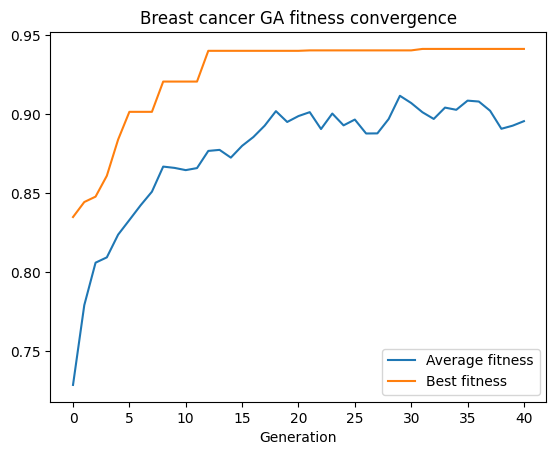

In [117]:
df_history = pd.DataFrame(history,columns = ["Generation","Average fitness","Best fitness"])
plot = df_history.plot(x="Generation", y = ["Average fitness","Best fitness"])
plot.set_title("Breast cancer GA fitness convergence")
plt.savefig("../images/ds3_GA_fc.png", dpi = 300)

In [118]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 2
Feature percentage: 0.0667


In [119]:
acc_test = evaluate_on_test_knn(best_solution, X_train_cancer, y_train_cancer, X_test_cancer, y_test_cancer)
print(f"Train accuracy of best solution (KNN): {best_train_accuracy:.4f}\nTest accuracy (RF): {acc_test:.4f}")

Train accuracy of best solution (KNN): 0.9496
Test accuracy (RF): 0.9298


In [120]:
ga_sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 30,
                 code = best_solution,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_cancer,
                 y_train = y_train_cancer,
                 calc_accuracy_fn = evaluate_selected_features_knn,
                 patience = 30)

In [121]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = ga_sa_extended.run()

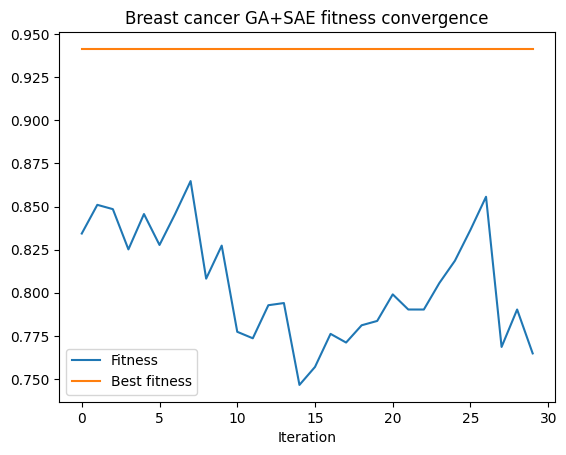

In [122]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Breast cancer GA+SAE fitness convergence")
plt.savefig("../images/ds3_GA+SAE_fc.png", dpi = 300)

In [123]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 2
Feature percentage: 0.0667


In [124]:
acc_test = evaluate_on_test_knn(best_solution, X_train_cancer, y_train_cancer, X_test_cancer, y_test_cancer)
print(f"Train accuracy of best solution (KNN): {best_train_acc:.4f}\nTest accuracy (KNN): {acc_test:.4f}")

Train accuracy of best solution (KNN): 0.9496
Test accuracy (KNN): 0.9298


In [125]:
best_position, best_train_acc, number_selected_features, best_fitness, best_history, average_history = BPSO.run(
    X_train = X_train_cancer,
    y_train = y_train_cancer,
    calc_accuracy_fn = evaluate_selected_features_knn,
    alpha = 0.5,
    num_iters = 50,
    swarm_size = 40,
    c_inertia_start = 1.1,
    c_inertia_end = 0.4,
    c_social = 1.0,
    c_cognitive = 2.0
)

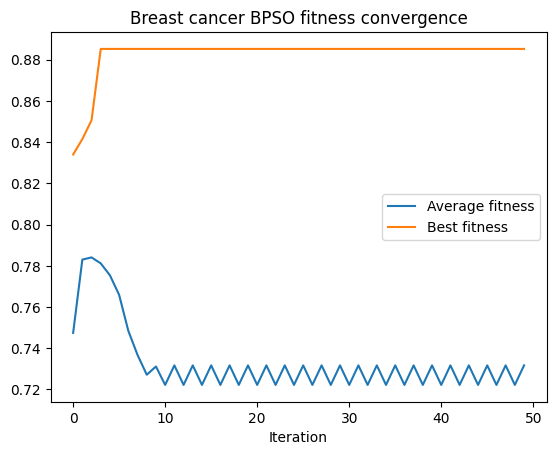

In [126]:
df_avg = pd.DataFrame(average_history, columns=["Iteration", "Average fitness"])
df_best = pd.DataFrame(best_history, columns=["Iteration", "Best fitness"])
df_history = pd.merge(df_avg, df_best, on="Iteration")

plot = df_history.plot(x="Iteration", y = ["Average fitness","Best fitness"])
plot.set_title("Breast cancer BPSO fitness convergence")
plt.savefig("../images/ds3_BPSO_fc.png", dpi = 300)

In [127]:
pct_sel_features = number_selected_features/len(best_position)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 5
Feature percentage: 0.1667


In [128]:
acc_test = evaluate_on_test_knn(best_position, X_train_cancer, y_train_cancer, X_test_cancer, y_test_cancer)
print(f"Train accuracy of best solution (KNN): {best_train_acc:.4f}\nTest accuracy (KNN): {acc_test:.4f}")

Train accuracy of best solution (KNN): 0.9372
Test accuracy (KNN): 0.9240


In [129]:
bpso_sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 100,
                 code = best_position,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_cancer,
                 y_train = y_train_cancer,
                 calc_accuracy_fn = evaluate_selected_features_knn,
                 patience = 30)

In [130]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = bpso_sa_extended.run()

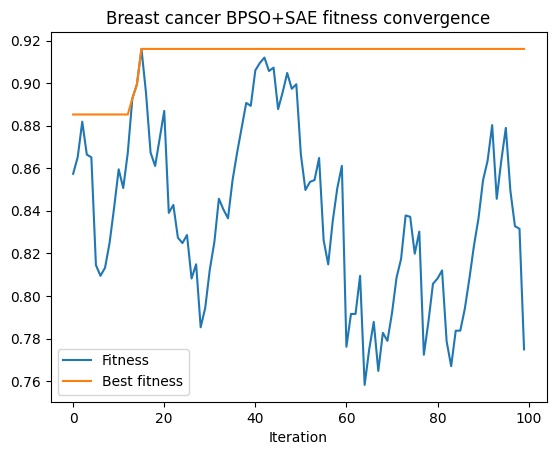

In [131]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Breast cancer BPSO+SAE fitness convergence")
plt.savefig("../images/ds3_BPSO+SAE_fc.png", dpi = 300)

In [132]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 3
Feature percentage: 0.1000


In [133]:
acc_test = evaluate_on_test_knn(best_solution, X_train_cancer, y_train_cancer, X_test_cancer, y_test_cancer)
print(f"Train accuracy of best solution (KNN): {best_train_acc:.4f}\nTest accuracy (KNN): {acc_test:.4f}")

Train accuracy of best solution (KNN): 0.9321
Test accuracy (KNN): 0.9064


In [134]:
initial_code = generate_code(X_train_cancer,0.5)

In [135]:
sa_extended = simulated_annealing.Simulated_Annealing_Extended(
                 num_iters = 100,
                 code = initial_code,
                 alpha = 0.5,
                 temperature = 1,
                 cooling_schedule = 'logarithmic',
                 cooling_factor = 0.99,
                 X_train = X_train_cancer,
                 y_train = y_train_cancer,
                 calc_accuracy_fn = evaluate_selected_features_knn,
                 patience = 30)

In [136]:
best_solution, best_train_acc, number_selected_features, best_fitness, history = sa_extended.run()

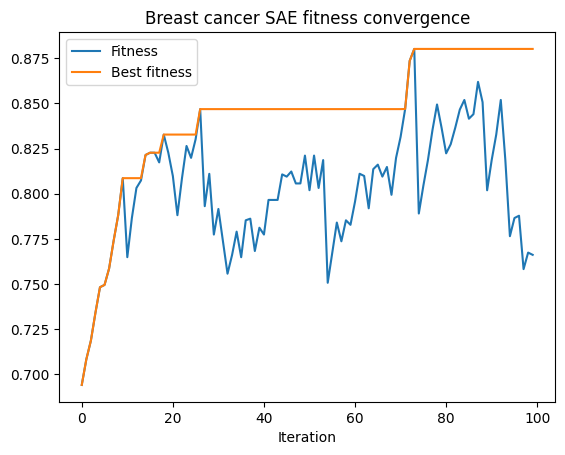

In [137]:
df_history = pd.DataFrame(history,columns = ["Iteration","Fitness","Best fitness"])
plot = df_history.plot(x="Iteration", y = ["Fitness","Best fitness"])
plot.set_title("Breast cancer SAE fitness convergence")
plt.savefig("../images/ds3_SAE_fc.png", dpi = 300)

In [138]:
pct_sel_features = number_selected_features/len(best_solution)
print(f"Number of selected features: {number_selected_features}\nFeature percentage: {pct_sel_features:.4f}")

Number of selected features: 5
Feature percentage: 0.1667


In [139]:
acc_test = evaluate_on_test_knn(best_solution, X_train_cancer, y_train_cancer, X_test_cancer, y_test_cancer)
print(f"Train accuracy of best solution (KNN): {best_train_acc:.4f}\nTest accuracy (KNN): {acc_test:.4f}")

Train accuracy of best solution (KNN): 0.9271
Test accuracy (KNN): 0.9474
